TASK 1

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
class_names = [str(i) for i in range(10)]
print("MNIST Dataset loaded successfully!")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST Dataset loaded successfully!


Displaying the first 10 images:


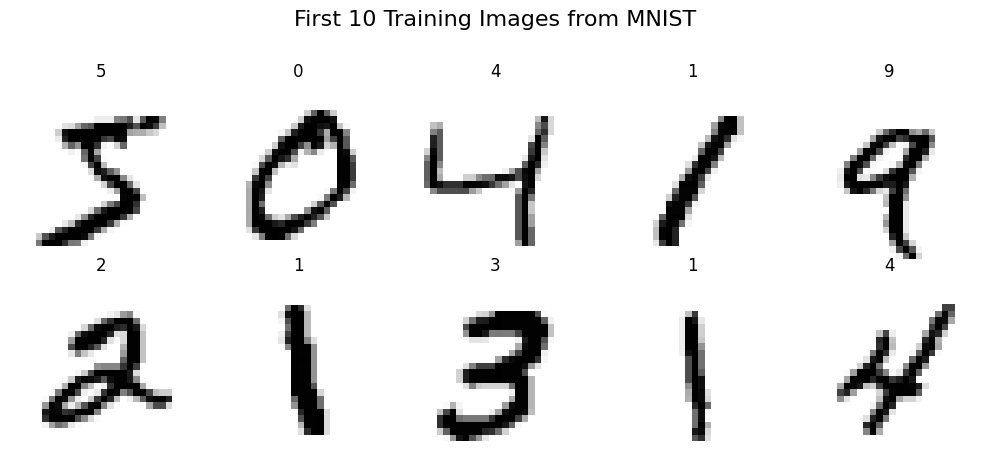

In [3]:
print('Displaying the first 10 images:')

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.title(class_names[train_labels[i]])
    plt.axis('off')
plt.suptitle('First 10 Training Images from MNIST', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [4]:
num_classes = len(np.unique(train_labels))
print(f"Number of classes: {num_classes}")
image_shape = train_images.shape[1:]
print(f"Image size (Height, Width): {image_shape}")

num_train_images = train_images.shape[0]
print(f"Number of training images: {num_train_images}")

num_test_images = test_images.shape[0]
print(f"Number of testing images: {num_test_images}")

print(f"Class names: {class_names}")

Number of classes: 10
Image size (Height, Width): (28, 28)
Number of training images: 60000
Number of testing images: 10000
Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


TASK 2


In [5]:
X_train = train_images.astype('float32') / 255.0
X_test = test_images.astype('float32') / 255.0

print("Pixel values normalized.")

Pixel values normalized.


In [6]:
y_train = tf.keras.utils.to_categorical(train_labels, num_classes=num_classes)
y_test = tf.keras.utils.to_categorical(test_labels, num_classes=num_classes)

print("Labels converted to one-hot encoding.")

Labels converted to one-hot encoding.


In [7]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (60000, 28, 28)
Shape of X_test: (10000, 28, 28)
Shape of y_train: (60000, 10)
Shape of y_test: (10000, 10)


TASK 3

In [8]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(f"New shape of X_train: {X_train.shape}")
print(f"New shape of X_test: {X_test.shape}")

New shape of X_train: (60000, 28, 28, 1)
New shape of X_test: (10000, 28, 28, 1)


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

print("CNN Model built successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Model built successfully!


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

TASK 4

In [11]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Model compiled successfully!")

Model compiled successfully!


In [12]:
batch_size = 64
epochs = 25

history = model.fit(X_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(X_test, y_test))

print("Model training complete!")

Epoch 1/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9537 - loss: 0.1547 - val_accuracy: 0.9853 - val_loss: 0.0443
Epoch 2/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9852 - loss: 0.0476 - val_accuracy: 0.9839 - val_loss: 0.0476
Epoch 3/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9896 - loss: 0.0324 - val_accuracy: 0.9860 - val_loss: 0.0405
Epoch 4/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9920 - loss: 0.0245 - val_accuracy: 0.9884 - val_loss: 0.0373
Epoch 5/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9938 - loss: 0.0184 - val_accuracy: 0.9902 - val_loss: 0.0304
Epoch 6/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9951 - loss: 0.0147 - val_accuracy: 0.9873 - val_loss: 0.0456
Epoch 7/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9962 - loss: 0.0118 - val_accuracy: 0.9921 - val_loss: 0.0270
Epoch 8/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9971 - loss: 0.0085 - val_accuracy: 0

TASK 5


In [13]:
print("Training History Summary:")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

Training History Summary:
Final Training Accuracy: 0.9999
Final Training Loss: 0.0006
Final Validation Accuracy: 0.9925
Final Validation Loss: 0.0430


TASK 6

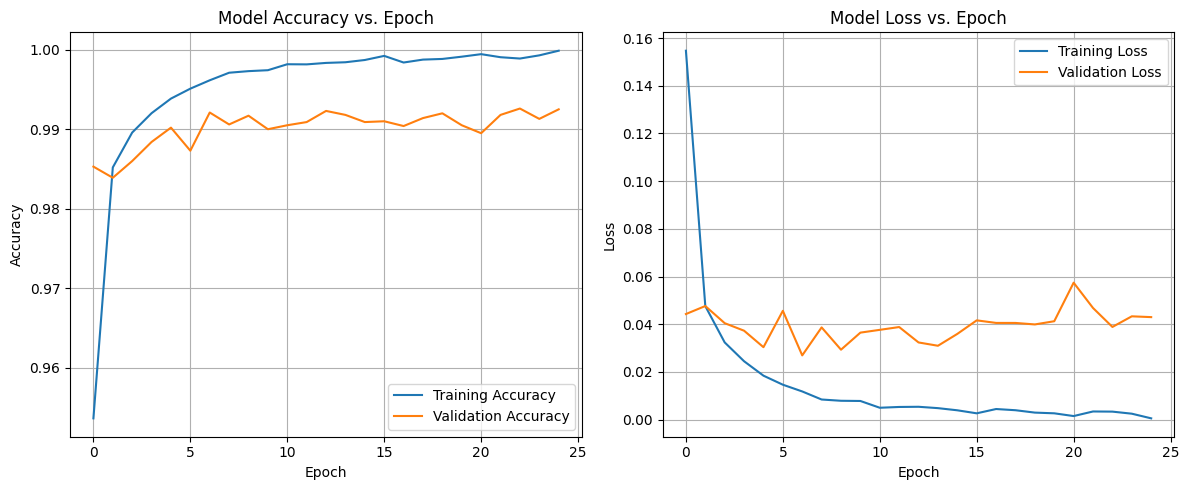

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

TASK 7

In [15]:
import numpy as np

num_test_samples = X_test.shape[0]
random_indices = np.random.choice(num_test_samples, 10, replace=False)

selected_test_images = X_test[random_indices]
selected_true_labels_one_hot = y_test[random_indices]
selected_true_labels = np.argmax(selected_true_labels_one_hot, axis=1)

print(f"Selected {len(random_indices)} random test images.")

Selected 10 random test images.


In [16]:
predictions = model.predict(selected_test_images)
predicted_labels = np.argmax(predictions, axis=1)

print("Predictions made for the selected images.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step
Predictions made for the selected images.


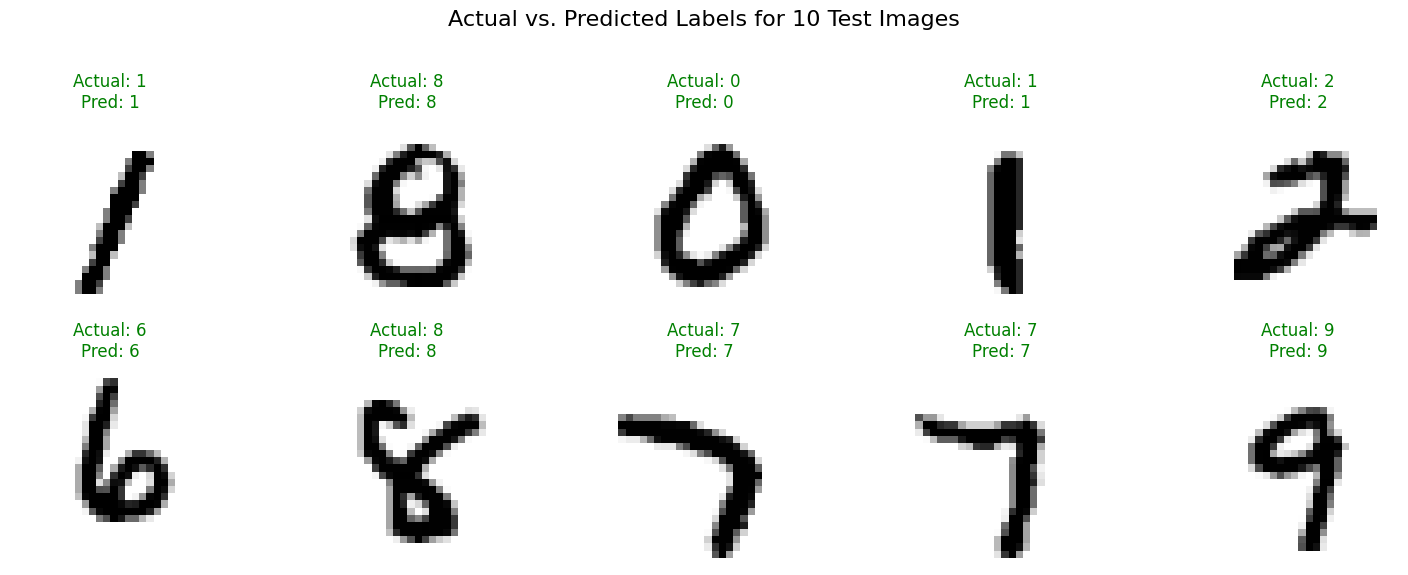

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(selected_test_images[i].reshape(28, 28), cmap=plt.cm.binary)

    actual_label = selected_true_labels[i]
    predicted_label = predicted_labels[i]

    color = 'green' if actual_label == predicted_label else 'red'
    plt.title(f"Actual: {actual_label}\nPred: {predicted_label}", color=color)
    plt.axis('off')

plt.suptitle('Actual vs. Predicted Labels for 10 Test Images', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

TASK 8


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model_improved = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

print("Improved CNN Model built successfully!")
model_improved.summary()

Improved CNN Model built successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,442 (947.04 KB)

 Trainable params: 241,994 (945.29 KB)

 Non-trainable params: 448 (1.75 KB)

In [19]:
model_improved.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

print("Improved model compiled successfully!")

Improved model compiled successfully!


In [20]:
history_improved = model_improved.fit(X_train, y_train,
                                        batch_size=batch_size,
                                        epochs=epochs,
                                        validation_data=(X_test, y_test))

print("Improved model training complete!")

Epoch 1/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9562 - loss: 0.1496 - val_accuracy: 0.9827 - val_loss: 0.0532
Epoch 2/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9814 - loss: 0.0632 - val_accuracy: 0.9897 - val_loss: 0.0362
Epoch 3/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9856 - loss: 0.0475 - val_accuracy: 0.9890 - val_loss: 0.0359
Epoch 4/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9894 - loss: 0.0364 - val_accuracy: 0.9890 - val_loss: 0.0402
Epoch 5/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9909 - loss: 0.0305 - val_accuracy: 0.9862 - val_loss: 0.0502
Epoch 6/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9913 - loss: 0.0294 - val_accuracy: 0.9901 - val_loss: 0.0392
Epoch 7/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9925 - loss: 0.0258 - val_accuracy: 0.9891 - val_loss: 0.0413
Epoch 8/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9931 - loss: 0.0240 - val_accuracy: 0

In [21]:
loss_improved, accuracy_improved = model_improved.evaluate(X_test, y_test, verbose=0)

print(f"\nImproved Model - Test Accuracy: {accuracy_improved:.4f}")
print(f"Improved Model - Test Loss: {loss_improved:.4f}")


Improved Model - Test Accuracy: 0.9929
Improved Model - Test Loss: 0.0523


In [22]:
print("\n--- Model Accuracy Comparison ---")
print(f"Original Model (Validation Accuracy): {history.history['val_accuracy'][-1]:.4f}")
print(f"Improved Model (Validation Accuracy): {accuracy_improved:.4f}")


--- Model Accuracy Comparison ---
Original Model (Validation Accuracy): 0.9925
Improved Model (Validation Accuracy): 0.9929


TASK 9

## Task 9: Confusion Matrix

In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_improved_one_hot = model_improved.predict(X_test)
y_pred_improved = np.argmax(y_pred_improved_one_hot, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Predictions generated for the improved model.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predictions generated for the improved model.


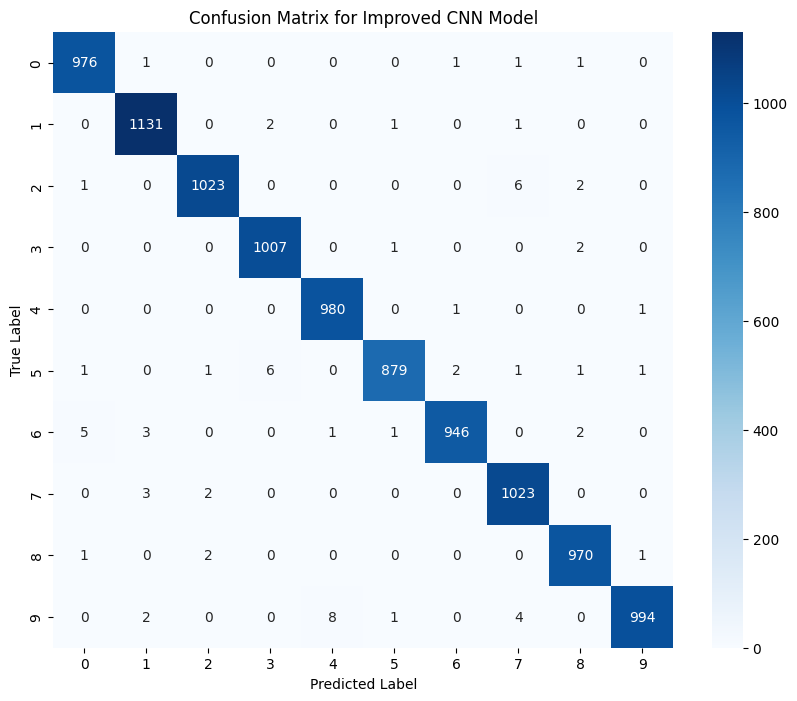

Confusion Matrix displayed.


In [24]:
cm = confusion_matrix(y_true, y_pred_improved)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for Improved CNN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
print("Confusion Matrix displayed.")

In [25]:
report = classification_report(y_true, y_pred_improved, target_names=class_names)
print("Classification Report for Improved CNN Model:")
print(report)

Classification Report for Improved CNN Model:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       1.00      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      1.00      0.99       982
           5       1.00      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       0.99      1.00      0.99       974
           9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



TASK 10 REPORT

### Why is CNN preferred over ANN for image classification?
CNNs are preferred due to their ability to automatically learn spatial features, share parameters, and achieve translational invariance, making them highly efficient for image data.

### What is the role of Conv2D?
Conv2D layers apply learnable filters to input images to automatically extract local features like edges and textures.

### Why is MaxPooling used?
MaxPooling2D layers reduce the spatial dimensions of feature maps (downsampling) and provide translational invariance by summarizing features in regions.

### Why is Flatten required?
Flatten converts the multi-dimensional output of convolutional layers into a 1D vector, preparing it for input into fully connected Dense layers.

### What does Softmax do?
Softmax transforms raw output scores into a probability distribution for multi-class classification, where values sum to 1.

### Which optimizer is used?
The **Adam optimizer** was used, which adaptively adjusts learning rates for efficient training.

### Which loss function is used?
The **categorical cross-entropy loss function** was used, which is standard for multi-class classification with one-hot encoded labels.

### How can overfitting be reduced?
Overfitting can be reduced through techniques like more data, data augmentation, regularization, dropout, batch normalization, early stopping, or simplifying the model architecture.